# Numerical experiments for *Bias versus Tail Concentration Tradeoffs for Stochastic Approximation Algorithms*

This notebook is the reproducibility companion to the manuscript. It contains the numerical experiments used in the current version:

1. adaptive sampling versus vanilla stochastic approximation under low and high oracle variance;
2. vanilla SA versus logarithmically and polynomially expanding projection balls; and
3. a fixed-time error histogram illustrating the finite-time bias--tail tradeoff.

Running all cells from top to bottom regenerates the four PNG files in the local `figures/` directory.


## Running and reproducing the experiments

- Use Python 3.10 or later with NumPy and Matplotlib. Exact tested versions are listed in `requirements.txt`.
- Run the notebook from top to bottom. All pseudo-random number generators use fixed seeds.
- Algorithms in the same comparison use the same oracle distribution and, where stated, common random numbers.
- The adaptive and percentile experiments use (20{,}000) paths. The fixed-time histogram uses (100{,}000) paths.
- Figure files are saved at 300 dpi under `figures/`.

The notebook runs without network access and requires no external datasets.


In [1]:
from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = ["#0072B2", "#D55E00", "#CC79A7"]
PERCENTILES = np.array([0.90, 0.99, 0.999])
PERCENTILE_LABELS = ["90th", "99th", "99.9th"]

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


## Stochastic-approximation model

The experiments use the one-dimensional random operator

\[
F(x,Y)=Yx+Y-0.9,
\]

with stochastic-approximation update

\[
x_{k+1}=x_k+\alpha_k\bigl(F(x_k,Y_k)-x_k\bigr).
\]

Every oracle distribution below satisfies \(\mathbb E[Y]=0.9\). Therefore \(\mathbb E[F(x,Y)]=0.9x\), and the unique fixed point is \(x^*=0\).


## Simulation functions

For a Bernoulli batch, drawing the number of upper outcomes from a binomial distribution is exactly equivalent to drawing every sample separately. For a Gaussian batch, the batch average is drawn directly from the exact distribution \(\mathcal N(\mu,\sigma^2/N_k)\). Both implementations are exact and memory-efficient.


In [2]:
def empirical_percentiles(x, x_star=0.0):
    """Return the selected empirical percentiles of squared error."""
    return np.quantile((x - x_star) ** 2, PERCENTILES)


def oracle_draws(rng, size, y_low, y_high, p_high=0.5, sampler="bernoulli"):
    """Draw either Gaussian or two-point Bernoulli oracle observations."""
    if sampler == "gaussian":
        mean = 0.5 * (y_low + y_high)
        std = 0.5 * (y_high - y_low)
        return rng.normal(mean, std, size=size)
    if sampler != "bernoulli":
        raise ValueError(f"Unknown sampler: {sampler}")
    high = rng.random(size) >= 1.0 - p_high
    return np.where(high, y_high, y_low)


def sa_update(x, y, alpha):
    """Apply one stochastic-approximation update."""
    return (1.0 + (y - 1.0) * alpha) * x + alpha * (y - 0.9)


def simulate_vanilla(
    n_paths, n_steps, seed, x0, y_low, y_high, alpha_fn, sampler="bernoulli"
):
    rng = np.random.default_rng(seed)
    x = np.full(n_paths, x0, dtype=float)
    result = np.empty((len(PERCENTILES), n_steps + 1))
    result[:, 0] = empirical_percentiles(x)
    for k in range(n_steps):
        y = oracle_draws(rng, n_paths, y_low, y_high, sampler=sampler)
        x = sa_update(x, y, alpha_fn(k))
        result[:, k + 1] = empirical_percentiles(x)
    return result


def simulate_adaptive(
    n_paths,
    budget_limit,
    seed,
    x0,
    y_low,
    y_high,
    alpha_fn,
    batch_fn,
    sampler="bernoulli",
):
    rng = np.random.default_rng(seed)
    x = np.full(n_paths, x0, dtype=float)
    budgets, result = [], []
    budget = 0
    k = 0
    while budget <= budget_limit:
        batch_size = int(batch_fn(k))
        if sampler == "gaussian":
            mean = 0.5 * (y_low + y_high)
            std = 0.5 * (y_high - y_low)
            y_bar = rng.normal(mean, std / np.sqrt(batch_size), size=n_paths)
        elif sampler == "bernoulli":
            high_count = rng.binomial(batch_size, 0.5, size=n_paths)
            y_bar = y_low + (y_high - y_low) * high_count / batch_size
        else:
            raise ValueError(f"Unknown sampler: {sampler}")
        x = sa_update(x, y_bar, alpha_fn(k))
        budget += batch_size
        budgets.append(budget)
        result.append(empirical_percentiles(x))
        k += 1
    return np.asarray(budgets), np.asarray(result).T


## Parameter presets

The parameter choices below reproduce the displayed manuscript figures. The two adaptive experiments share every setting except the Gaussian oracle variance.


In [3]:
N_PATHS = 20_000

ADAPTIVE_COMMON = dict(
    seed_vanilla=1,
    seed_adaptive=1,
    sampler="gaussian",
    x0=0.4,
    x_star=0.0,
    h=120.0,
    alpha=60.0,
    m=0.3,
    beta=0.6,
    budget=300,
)
ADAPTIVE_COMMON["alpha_fn"] = lambda k: (
    ADAPTIVE_COMMON["alpha"] / (k + ADAPTIVE_COMMON["h"])
)
ADAPTIVE_COMMON["batch_fn"] = lambda k: math.ceil(
    ADAPTIVE_COMMON["m"]
    * (k + ADAPTIVE_COMMON["h"]) ** ADAPTIVE_COMMON["beta"]
)

ADAPTIVE_SMALL = dict(y_low=0.88, y_high=0.92, variance=0.0004)
ADAPTIVE_LARGE = dict(y_low=0.30, y_high=1.50, variance=0.36)


## Adaptive sampling versus vanilla SA

Both experiments start from \(x_0=0.4\), so the initialization error is nonzero. They use

\[
\alpha_k=\frac{60}{k+120},
\qquad
N_k=\left\lceil0.3(k+120)^{0.6}\right\rceil.
\]

The oracle is Gaussian with mean \(0.9\). The horizontal axis counts cumulative oracle calls rather than iterations, so the comparison includes the sampling cost of each adaptive update. The low-variance experiment uses \(\operatorname{Var}(Y)=0.0004\), while the high-variance experiment uses \(\operatorname{Var}(Y)=0.36\).


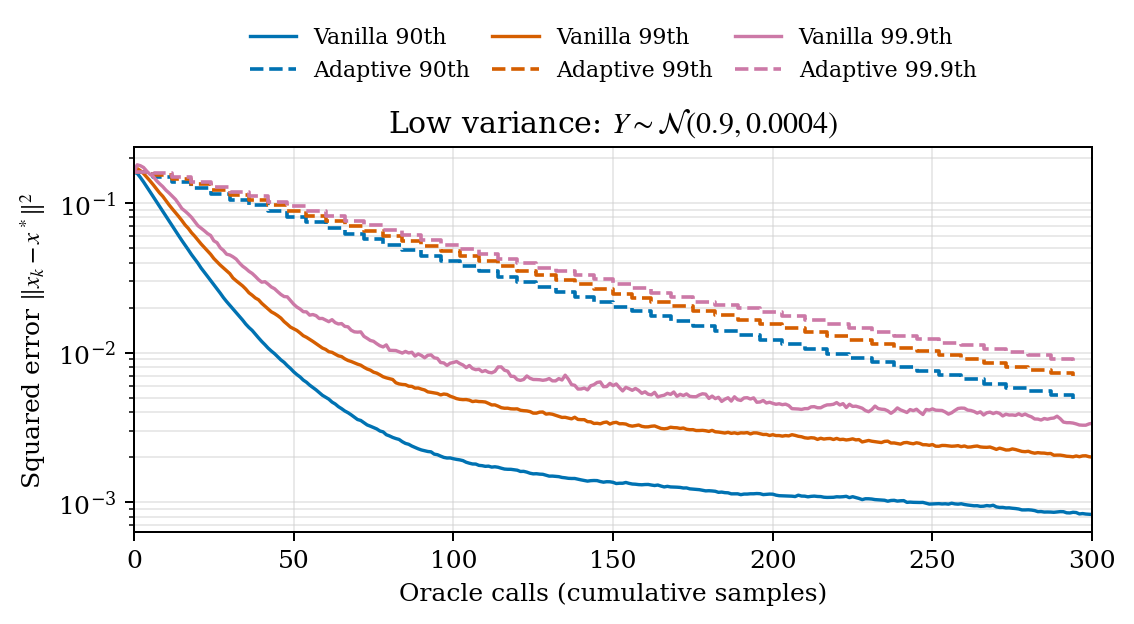

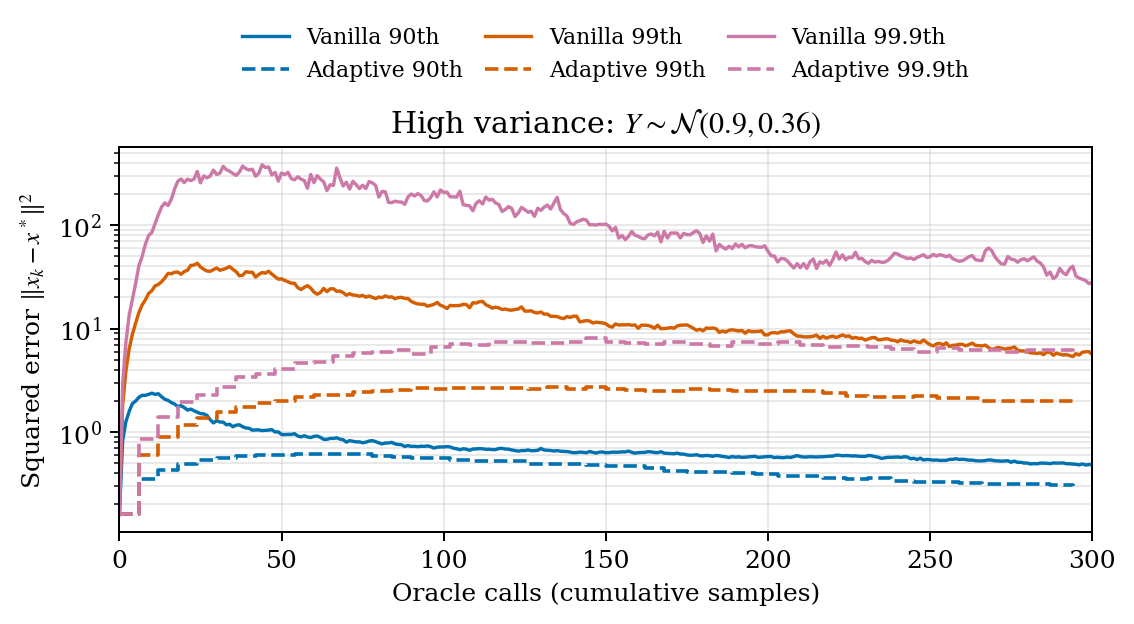

In [4]:
def adaptive_budget_curves(regime):
    cfg = ADAPTIVE_COMMON
    vanilla = simulate_vanilla(
        N_PATHS, cfg['budget'], cfg['seed_vanilla'], cfg['x0'],
        regime['y_low'], regime['y_high'], cfg['alpha_fn'], cfg['sampler'])
    budgets, adaptive = simulate_adaptive(
        N_PATHS, cfg['budget'], cfg['seed_adaptive'], cfg['x0'],
        regime['y_low'], regime['y_high'], cfg['alpha_fn'], cfg['batch_fn'],
        cfg['sampler'])
    keep = budgets <= cfg['budget']
    budgets = np.concatenate(([0], budgets[keep]))
    initial = empirical_percentiles(np.full(N_PATHS, cfg['x0']), cfg['x_star'])
    adaptive = np.column_stack((initial, adaptive[:, keep]))
    return vanilla, budgets, adaptive


def plot_adaptive_budget_comparison(regime, title, filename):
    cfg = ADAPTIVE_COMMON
    vanilla, budgets, adaptive = adaptive_budget_curves(regime)
    fig, ax = plt.subplots(figsize=(6.4, 3.65), dpi=180)
    calls = np.arange(cfg['budget'] + 1)
    for i, (color, label) in enumerate(zip(COLORS, PERCENTILE_LABELS)):
        ax.semilogy(calls, vanilla[i], color=color, lw=1.35,
                    label=f'Vanilla {label}')
        ax.step(budgets, adaptive[i], where='post', color=color, ls='--',
                lw=1.45, label=f'Adaptive {label}')
    ax.set(xlim=(0, cfg['budget']), xlabel='Oracle calls (cumulative samples)',
           ylabel=r'Squared error $\|x_k-x^*\|^2$', title=title)
    ax.grid(True, which='both', color='#cfcfcf', alpha=0.6, lw=0.6)
    ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.12),
              frameon=False, columnspacing=1.0, handlelength=2.1, fontsize=8.8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return vanilla, budgets, adaptive


fig1a_vanilla, fig1a_budgets, fig1a_adaptive = plot_adaptive_budget_comparison(
    ADAPTIVE_SMALL,
    r'Low variance: $Y\sim\mathcal{N}(0.9,0.0004)$',
    'figure_1a_adaptive_small_variance.png')
fig1b_vanilla, fig1b_budgets, fig1b_adaptive = plot_adaptive_budget_comparison(
    ADAPTIVE_LARGE,
    r'High variance: $Y\sim\mathcal{N}(0.9,0.36)$',
    'figure_1b_adaptive_large_variance.png')

## Polynomial and logarithmic expanding balls

This comparison uses the mean-contractive Bernoulli oracle \(Y\in\{0.30,1.50\}\) with equal probabilities. Vanilla SA, an \(x_0\)-centered logarithmic ball, and the manuscript's \(x_0\)-centered polynomial ball start from \(x_0=10\) and use the same oracle samples along each matched path.

Both balls have \(B_1=10=|x_0-x^*|\), so they contain the target from the first update and introduce no initial boundary-exclusion penalty. Over the displayed horizon, the polynomial schedule with \(r=1/2\) is more restrictive than the matched logarithmic schedule. Separate logarithmic-scale panels report the 90th, 99th, and 99.9th percentiles.


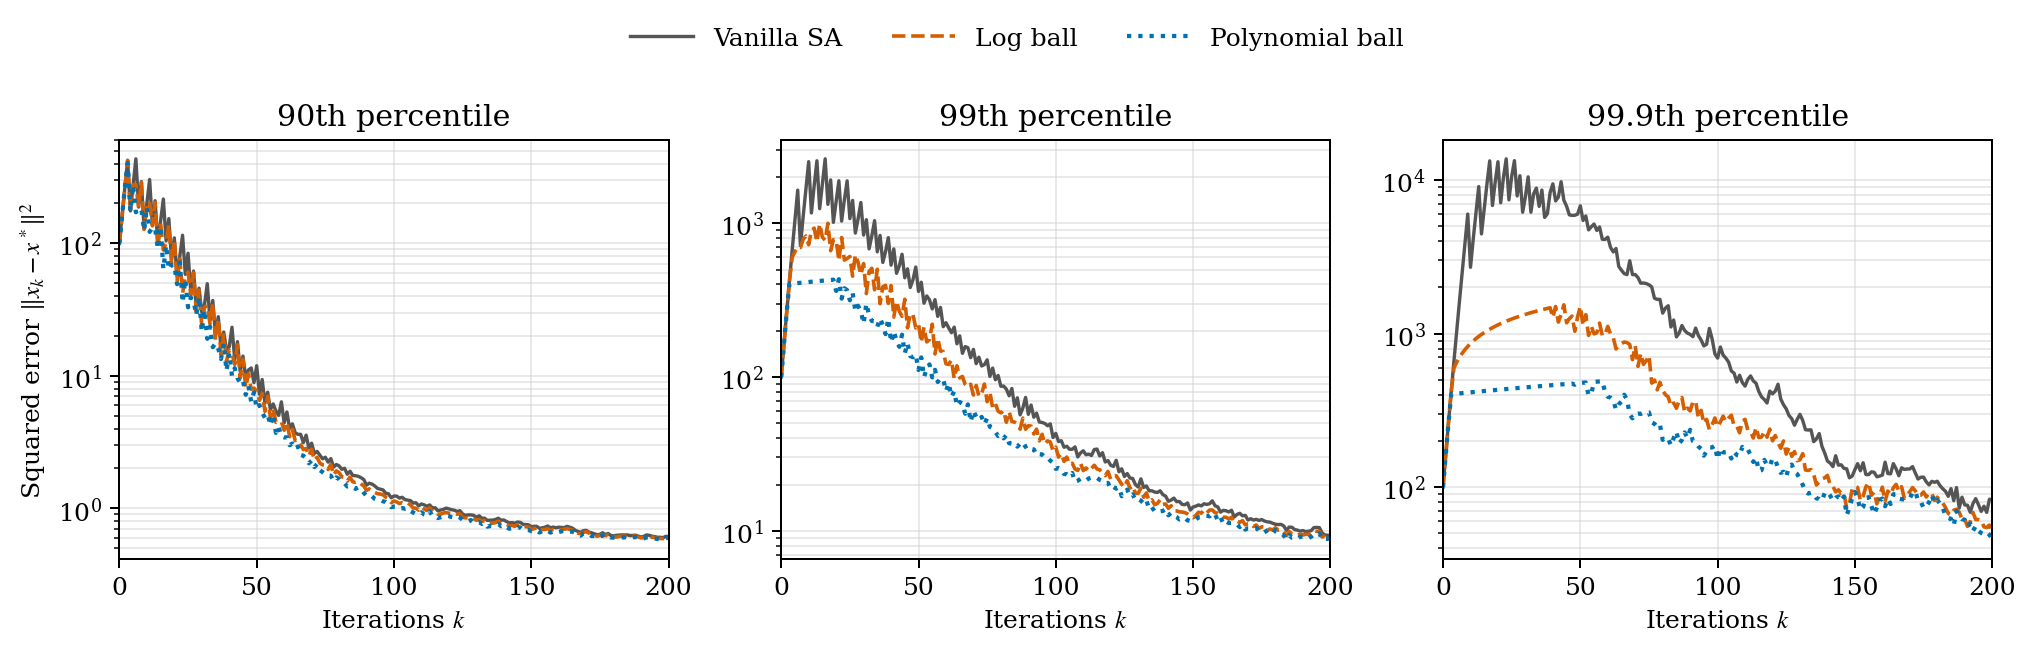

Matched first radius: B_1 = 10.0
Log-ball containment index: k_B = 1
Polynomial-ball containment index: k_B = 1
Polynomial coefficient: c_r = 0.909091


In [5]:
def simulate_radius_comparison(n_paths, n_steps, seed, x0, x_star, y_low, y_high,
                               alpha_fn, initial_radius, r, h, sampler='bernoulli'):
    """Use common oracle samples for vanilla, x0-log-ball, and x0-polynomial-ball SA."""
    rng = np.random.default_rng(seed)
    center = x0
    x_vanilla = np.full(n_paths, x0, dtype=float)
    x_log = x_vanilla.copy()
    x_poly = x_vanilla.copy()
    result_vanilla = np.empty((len(PERCENTILES), n_steps + 1))
    result_log = np.empty_like(result_vanilla)
    result_poly = np.empty_like(result_vanilla)
    initial_error = empirical_percentiles(x_vanilla, x_star)
    result_vanilla[:, 0] = initial_error
    result_log[:, 0] = initial_error
    result_poly[:, 0] = initial_error

    # Match B_1 exactly; only the subsequent growth laws differ.
    c_log = initial_radius / np.log(1.0 + np.e)
    c_poly = initial_radius / (1.0 + h) ** r
    for k in range(n_steps):
        y = oracle_draws(rng, n_paths, y_low, y_high, sampler=sampler)
        candidate_vanilla = sa_update(x_vanilla, y, alpha_fn(k))
        candidate_log = sa_update(x_log, y, alpha_fn(k))
        candidate_poly = sa_update(x_poly, y, alpha_fn(k))
        radius_log = c_log * np.log(k + 1 + np.e)
        radius_poly = c_poly * (k + 1 + h) ** r
        x_vanilla = candidate_vanilla
        x_log = center + np.clip(candidate_log - center, -radius_log, radius_log)
        x_poly = center + np.clip(candidate_poly - center, -radius_poly, radius_poly)
        result_vanilla[:, k + 1] = empirical_percentiles(x_vanilla, x_star)
        result_log[:, k + 1] = empirical_percentiles(x_log, x_star)
        result_poly[:, k + 1] = empirical_percentiles(x_poly, x_star)
    return result_vanilla, result_log, result_poly, c_log, c_poly


FIG3 = dict(n_steps=200, seed=361, x0=10.0, x_star=0.0,
            y_low=0.30, y_high=1.50, h=120.0,
            initial_radius=10.0, r=0.5, sampler='bernoulli')
FIG3['alpha_fn'] = lambda k: 60.0 / (k + FIG3['h'])
fig3_vanilla, fig3_log, fig3_poly, c_log, c_poly = simulate_radius_comparison(
    N_PATHS, FIG3['n_steps'], FIG3['seed'], FIG3['x0'], FIG3['x_star'],
    FIG3['y_low'], FIG3['y_high'], FIG3['alpha_fn'],
    FIG3['initial_radius'], FIG3['r'], FIG3['h'], FIG3['sampler'])
distance = abs(FIG3['x_star'] - FIG3['x0'])
k_B_log = max(0, math.ceil(np.exp(distance / c_log) - np.e - 1e-12))
k_B_poly = max(0, math.ceil(
    (distance / c_poly) ** (1.0 / FIG3['r']) - FIG3['h'] - 1e-12))

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.6), dpi=180)
iterations = np.arange(FIG3['n_steps'] + 1)
method_colors = {'Vanilla SA': '#555555', 'Log ball': '#D55E00',
                 'Polynomial ball': '#0072B2'}
for i, (ax, percentile_label) in enumerate(zip(axes, PERCENTILE_LABELS)):
    ax.semilogy(iterations, fig3_vanilla[i], color=method_colors['Vanilla SA'],
                lw=1.35, label='Vanilla SA')
    ax.semilogy(iterations, fig3_log[i], color=method_colors['Log ball'],
                ls='--', lw=1.45, label='Log ball')
    ax.semilogy(iterations, fig3_poly[i], color=method_colors['Polynomial ball'],
                ls=':', lw=1.7, label='Polynomial ball')
    ax.set(xlim=(0, FIG3['n_steps']), xlabel=r'Iterations $k$',
           title=f'{percentile_label} percentile')
    ax.grid(True, which='both', color='#cfcfcf', alpha=0.6, lw=0.6)
axes[0].set_ylabel(r'Squared error $\|x_k-x^*\|^2$')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc='upper center', frameon=False,
           bbox_to_anchor=(0.5, 1.01), handlelength=2.5)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(OUTPUT_DIR / 'figure_3_polynomial_ball_vs_vanilla.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Matched first radius: B_1 = {FIG3['initial_radius']}")
print(f"Log-ball containment index: k_B = {k_B_log}")
print(f"Polynomial-ball containment index: k_B = {k_B_poly}")
print(f"Polynomial coefficient: c_r = {c_poly:.6g}")

## Fixed-time error histogram: projection bias versus tail control

This diagnostic uses the pathwise signed error at the single final iteration \(k=200\); it does not pool errors over time. The mean-contractive Bernoulli oracle is \(Y\in\{0,1.8\}\) with equal probabilities, and all three algorithms use the same oracle samples. Both \(x_0\)-centered balls have matched initial radius \(B_1=2\), so their projection bias remains visible at the snapshot.

Dotted vertical lines mark empirical signed means. The annotations report absolute bias \(|\mathbb E[x_k-x^*]|\) and the 99.9th percentile of \(|x_k-x^*|\). At \(k=200\), the logarithmic and polynomial iterates are supported on approximately \([1.91,18.09]\) and \([6.75,13.25]\), respectively. Proposals outside these intervals are mapped to the nearest boundary, so out-of-ball observations cannot appear in the post-projection histogram; extreme proposals instead contribute mass at the endpoints.


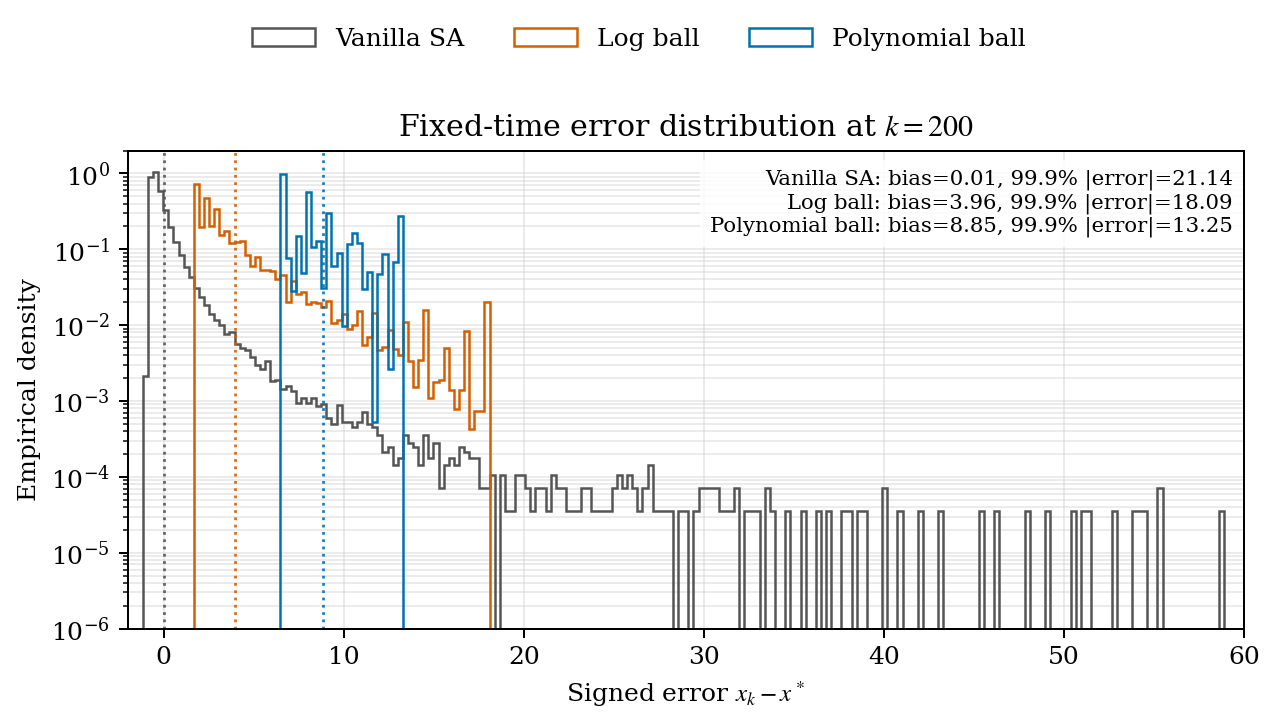

Vanilla SA: bias=0.01, 99.9% |error|=21.14
Log ball: bias=3.96, 99.9% |error|=18.09
Polynomial ball: bias=8.85, 99.9% |error|=13.25


In [6]:
def simulate_error_snapshot(n_paths, snapshot_k, seed, x0, x_star, y_low, y_high,
                            alpha_fn, initial_radius, r, h, sampler='bernoulli'):
    """Return pathwise signed errors at one fixed iteration for all three methods."""
    rng = np.random.default_rng(seed)
    x_vanilla = np.full(n_paths, x0, dtype=float)
    x_log = x_vanilla.copy()
    x_poly = x_vanilla.copy()
    c_log = initial_radius / np.log(1.0 + np.e)
    c_poly = initial_radius / (1.0 + h) ** r
    for k in range(snapshot_k):
        y = oracle_draws(rng, n_paths, y_low, y_high, sampler=sampler)
        candidate_vanilla = sa_update(x_vanilla, y, alpha_fn(k))
        candidate_log = sa_update(x_log, y, alpha_fn(k))
        candidate_poly = sa_update(x_poly, y, alpha_fn(k))
        radius_log = c_log * np.log(k + 1 + np.e)
        radius_poly = c_poly * (k + 1 + h) ** r
        x_vanilla = candidate_vanilla
        x_log = x0 + np.clip(candidate_log - x0, -radius_log, radius_log)
        x_poly = x0 + np.clip(candidate_poly - x0, -radius_poly, radius_poly)
    return {
        'Vanilla SA': x_vanilla - x_star,
        'Log ball': x_log - x_star,
        'Polynomial ball': x_poly - x_star,
    }


HISTOGRAM = dict(n_paths=100_000, snapshot_k=200, seed=361,
                 x0=10.0, x_star=0.0, y_low=0.00, y_high=1.80,
                 h=120.0, alpha=60.0, initial_radius=2.0, r=0.5,
                 sampler='bernoulli')
HISTOGRAM['alpha_fn'] = lambda k: HISTOGRAM['alpha'] / (k + HISTOGRAM['h'])
snapshot_errors = simulate_error_snapshot(
    HISTOGRAM['n_paths'], HISTOGRAM['snapshot_k'], HISTOGRAM['seed'],
    HISTOGRAM['x0'], HISTOGRAM['x_star'], HISTOGRAM['y_low'], HISTOGRAM['y_high'],
    HISTOGRAM['alpha_fn'], HISTOGRAM['initial_radius'], HISTOGRAM['r'],
    HISTOGRAM['h'], HISTOGRAM['sampler'])

histogram_colors = {'Vanilla SA': '#555555', 'Log ball': '#D55E00',
                    'Polynomial ball': '#0072B2'}
fig, ax = plt.subplots(figsize=(7.2, 4.1), dpi=180)
bins = np.linspace(-2.0, 60.0, 220)
summary_lines = []
for name, error in snapshot_errors.items():
    color = histogram_colors[name]
    ax.hist(error, bins=bins, density=True, histtype='step', lw=1.7,
            color=color, label=name)
    ax.axvline(np.mean(error), color=color, ls=':', lw=1.1, alpha=0.9)
    bias = abs(np.mean(error))
    tail = np.quantile(np.abs(error), 0.999)
    summary_lines.append(f'{name}: bias={bias:.2f}, 99.9% |error|={tail:.2f}')
ax.set_yscale('log')
ax.set(xlim=(-2, 60), ylim=(1e-6, 2),
       xlabel=r'Signed error $x_k-x^*$', ylabel='Empirical density',
       title=rf'Fixed-time error distribution at $k={HISTOGRAM["snapshot_k"]}$')
ax.grid(True, which='both', color='#cfcfcf', alpha=0.55, lw=0.6)
ax.text(0.99, 0.96, '\n'.join(summary_lines), transform=ax.transAxes,
        ha='right', va='top', fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.82, edgecolor='none'))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc='upper center', frameon=False,
           bbox_to_anchor=(0.5, 0.99), handlelength=2.5)
fig.tight_layout(rect=(0, 0, 1, 0.88))
fig.savefig(OUTPUT_DIR / 'figure_3b_ball_error_histogram_k200.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('\n'.join(summary_lines))

## Generated files

Running the notebook writes the following files to `figures/`:

- `figure_1a_adaptive_small_variance.png`
- `figure_1b_adaptive_large_variance.png`
- `figure_3_polynomial_ball_vs_vanilla.png`
- `figure_3b_ball_error_histogram_k200.png`



In [7]:
# Optional Google Colab downloads:
# from google.colab import files
# files.download(str(OUTPUT_DIR / "figure_1a_adaptive_small_variance.png"))
# files.download(str(OUTPUT_DIR / "figure_1b_adaptive_large_variance.png"))
# files.download(str(OUTPUT_DIR / "figure_3_polynomial_ball_vs_vanilla.png"))
# files.download(str(OUTPUT_DIR / "figure_3b_ball_error_histogram_k200.png"))
